In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_human_capital import ModelClass, constraints

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint

from IPython.display import display, Math

from plots import plot_series

model = ModelClass()

par = model.par
sol = model.sol
sim = model.sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This model is used to find a certain condition. Currently, I just minimize the change in average wage level, because it was not easy to get by just setting parameters.

In [3]:
def apply_params(par, names, values):
    for name, val in zip(names, values):
        setattr(par, name, float(val))
    return par

param_spec = {
    "shape_a": {"value": par.shape_a, "bounds": (0.001, 10.0), "active": True},
    "shape_b": {"value": par.shape_b, "bounds": (0.001, 5.0), "active": True},
    "shape_c": {"value": par.shape_c, "bounds": (0.00001, 0.5), "active": True},
    "phi":   {"value": par.phi,  "bounds": (0.01, 0.99),  "active": True},
    "alpha":    {"value": par.alpha,  "bounds": (0.01, 0.99),  "active": True},
    "mu":     {"value": par.mu,  "bounds": (1.0, 10.0), "active": True},
    "c":        {"value": par.c,  "bounds": (0.1, 1000.0),  "active": True},
}


active_names = [k for k, v in param_spec.items() if v["active"]]
x0 = np.array([param_spec[k]["value"] for k in active_names], dtype=float)
bounds = [param_spec[k]["bounds"] for k in active_names]


In [4]:
age_start_young = 25 - 25
age_end_young = age_start_young + 10
age_start_old = 55 - 25
age_end_old = age_start_old + 10

In [ ]:
def objective(x):
    # Initialize all non-active parameters to their default values
    model.setup()

    for name, spec in param_spec.items():
        if not spec["active"]:
            setattr(par, name, spec["value"])

    apply_params(par, active_names, x)

    model.update_params()

    model.solve(do_print=False)

    model.simulate_transition()

    wage_gap_sim = (
        np.average(model.sim.avg_wage[:, age_start_old:age_end_old] / model.sim.avg_wage[0, age_start_old:age_end_old], axis=1)
        - np.average(model.sim.avg_wage[:, age_start_young:age_end_young] / model.sim.avg_wage[0, age_start_young:age_end_young], axis=1)
    ) * 100

    wage_gap_data = np.loadtxt('Exogenous_estimation/wage_gap_data_mock.csv', delimiter=',')[1:]

    SSE = np.sum((wage_gap_sim - wage_gap_data)**2)

    # print(list(x), SSE )

    return SSE


def optimize_and_plot(single_run=True, optimizer_trials=2):
    runs = []

    n_runs = 1 if single_run else optimizer_trials

    for i in range(n_runs):
        x0_random = np.array([np.random.uniform(low, high) for (low, high) in bounds], dtype=float)

        result = minimize(
            objective,
            x0=x0_random,
            bounds=bounds,
            method="Nelder-Mead",
            options={'maxiter': 20000, 'disp': False}
        )

        runs.append(result)

        print(list(result.x), result.fun)

    model.setup()

    result = min(runs, key=lambda r: r.fun)

    optimized_values = result.x
    apply_params(par, active_names, optimized_values)

    model.update_params()

    print("Success:", result.success)
    print("Message:", result.message)
    print("Objective value:", result.fun)
    print("Optimized parameters:")
    for name in active_names:
        print("par." + name + " = ", getattr(par, name))

    
    model.solve()
    model.simulate_transition()

    wage_gap = (
        np.average(model.sim.avg_wage[:, age_start_old:age_end_old] / model.sim.avg_wage[0, age_start_old:age_end_old], axis=1)
        - np.average(model.sim.avg_wage[:, age_start_young:age_end_young] / model.sim.avg_wage[0, age_start_young:age_end_young], axis=1)
    ) * 100

    plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")

    return runs, optimized_values

runs, optimized_values = optimize_and_plot(single_run=False, optimizer_trials=100)

[0.8376110044441749, 3.0046194935150305, 0.318538464364331, 0.99, 0.01, 4.637472249994655, 808.6669974742454] 6521.184178350304


c:\Users\Peter\Documents\GitHub\Danish-Wage-Gap-Model\main_human_capital.py:80: RuntimeWarning: overflow encountered in exp
  par.Q_a = par.shape_c * np.exp(x / par.shape_a - par.shape_b) / (1 + np.exp(x / par.shape_a - par.shape_b))
c:\Users\Peter\Documents\GitHub\Danish-Wage-Gap-Model\main_human_capital.py:80: RuntimeWarning: invalid value encountered in divide
  par.Q_a = par.shape_c * np.exp(x / par.shape_a - par.shape_b) / (1 + np.exp(x / par.shape_a - par.shape_b))


[0.3180926303028341, 0.16706523192577766, 0.11386758494676806, 0.99, 0.99, 1.9346501087049264, 999.9998640607948] 7777.768262633475
[5.495683602391004, 0.6998522450437347, 0.2929738571041808, 0.99, 0.01, 9.250941992305844, 369.47876379810384] 6583.540793632004
[6.84319235236803, 0.37121441251944187, 0.04209439562454226, 0.6104684258401516, 0.04464526937519753, 1.0, 485.8643461014907] 7747.08907012642


par.Q_a_shape =  0.010803331101928994
par.phi =  0.24876819368685998
par.alpha =  0.13263586349475298
par.mu =  9.99999993692364
par.c =  0.10000000000011944
1598.6292214274265


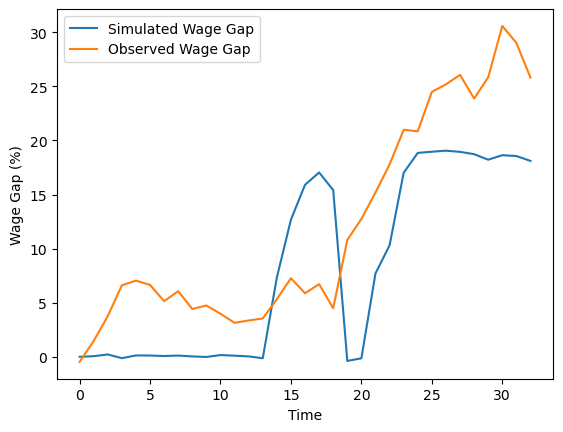

: 

In [ ]:
model.setup()

# optimized_values = [np.float64(0.623961436054632), np.float64(0.383503115066401), np.float64(10.0), np.float64(84.00874005478093)]
optimized_values = [0.010803331101928994, 0.24876819368685998, 0.13263586349475298, 9.99999993692364, 0.10000000000011944]

apply_params(par, active_names, optimized_values)

for name in active_names:
    print("par." + name + " = ", getattr(par, name))

model.update_params()

model.solve()
model.simulate_transition()



wage_gap = (
    np.average(model.sim.avg_wage[:, -groups::] / model.sim.avg_wage[0, -groups::], axis=1)
    - np.average(model.sim.avg_wage[:, :groups] / model.sim.avg_wage[0, :groups], axis=1)
) * 100

data = np.loadtxt('Exogenous_estimation/wage_gap_data_mock.csv', delimiter=',')[1:]

print(np.sum((wage_gap - data)**2))

plt.plot(wage_gap, label='Simulated Wage Gap')
plt.plot(data, label='Observed Wage Gap')
plt.xlabel('Time')
plt.ylabel('Wage Gap (%)')
plt.legend()
plt.show()

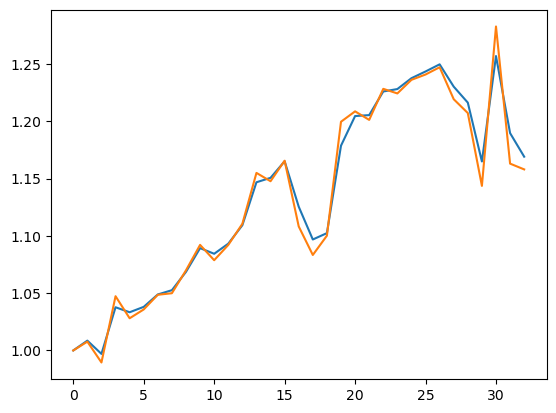

: 

In [ ]:
plt.plot(np.average(model.sim.avg_wage[:, -1::] / model.sim.avg_wage[0, -1::], axis=1))
plt.plot(model.sim.avg_wage[:, 0] / model.sim.avg_wage[0, 0])

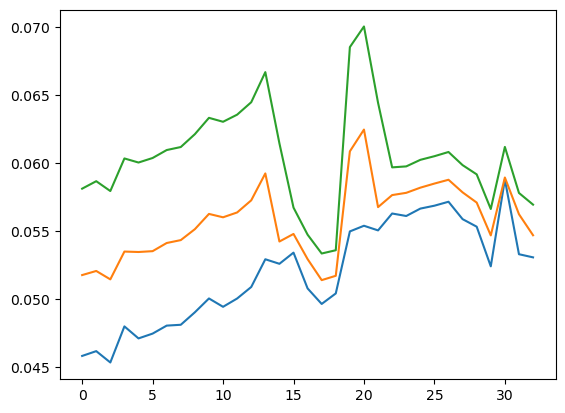

: 

In [ ]:
plt.plot(model.sim.avg_wage[:, 0])
plt.plot(model.sim.avg_wage[:, 1])
plt.plot(model.sim.avg_wage[:, 2])

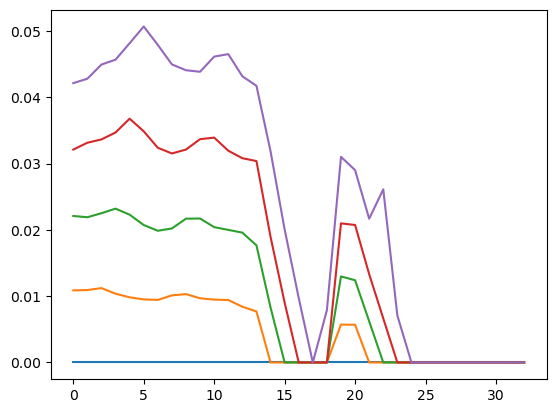

: 

In [ ]:
plt.plot(model.sim.l_h[:, age_start_young:age_end_young])

40

: 

In [ ]:
model.sim

namespace(l_h=array([[0.        , 0.01087898, 0.02210278, ..., 0.00114413, 0.00098499,
                      0.00069992],
                     [0.        , 0.01093108, 0.02191327, ..., 0.00096447, 0.00087877,
                      0.00065063],
                     [0.        , 0.01121918, 0.02251883, ..., 0.00095502, 0.00067598,
                      0.00062105],
                     ...,
                     [0.        , 0.        , 0.        , ..., 0.01089286, 0.009454  ,
                      0.00803425],
                     [0.        , 0.        , 0.        , ..., 0.01082667, 0.00943468,
                      0.00817226],
                     [0.        , 0.        , 0.        , ..., 0.01109143, 0.00892287,
                      0.00786666]]),
          l_l=array([[1.00000000e+00, 9.96123017e-01, 1.00085854e+00, ...,
                      1.10917254e-03, 9.14484272e-04, 6.22268778e-04],
                     [1.00865938e+00, 1.00089412e+00, 9.92277008e-01, ...,
                   

: 

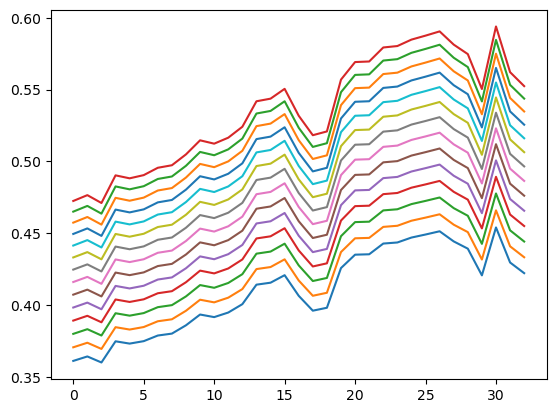

: 

In [ ]:
plt.plot(model.sim.avg_wage[:, age_start_old:-1])

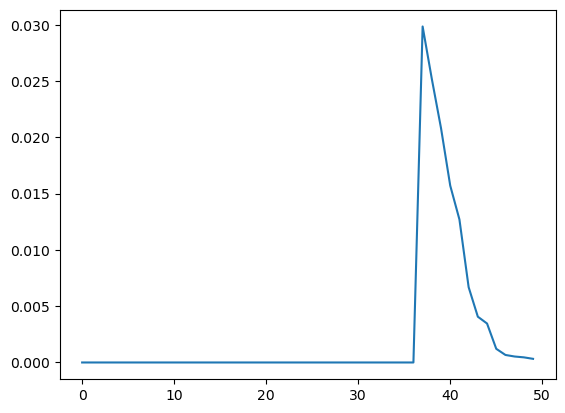

: 

In [ ]:
plt.plot(model.sim.l_h[0, :])

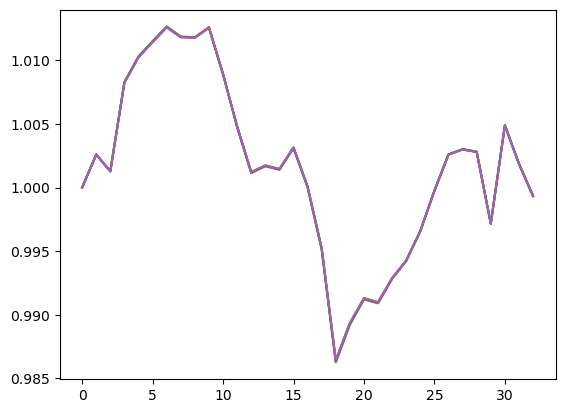

: 

In [ ]:
plt.plot(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::])

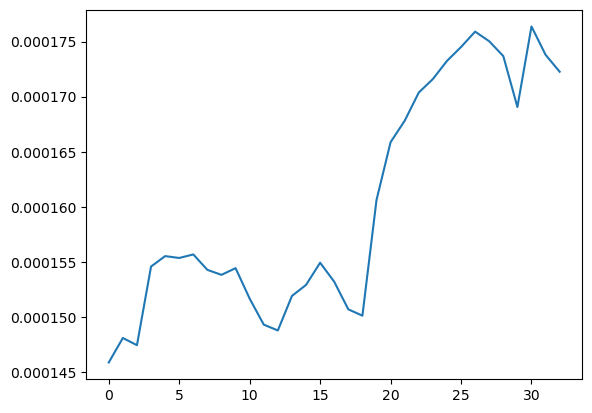

: 

In [ ]:
plt.plot(model.sim.avg_wage[:, -1])

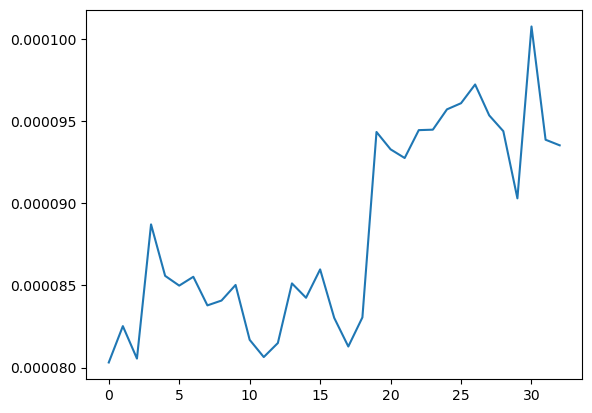

: 

In [ ]:
plt.plot(model.sim.avg_wage[:, 0])

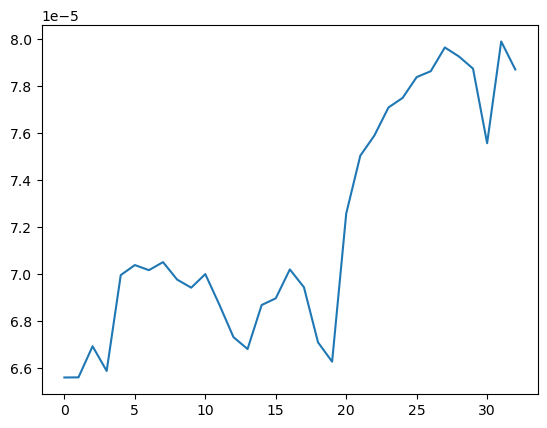

: 

In [ ]:
plt.plot(model.sim.avg_wage[:, -1] - model.sim.avg_wage[:, 0], label='Simulated Wage Gap')

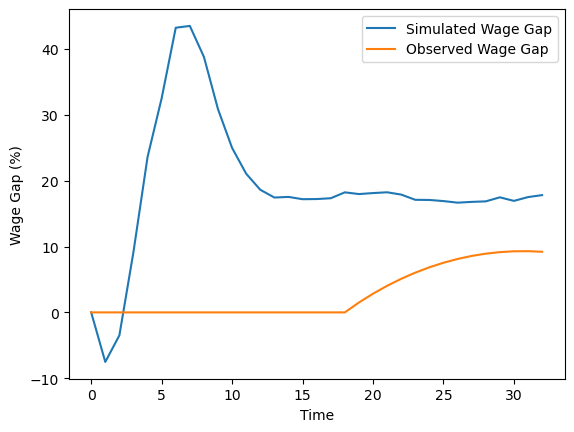

: 